#  Sentiment Analysis of Financial News
### Using Simple RNN, LSTM, and LSTM with Word2Vec Embeddings



**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Institution:** Herald College, Kathmandu  
**Assessment:** Part III – Natural Language Processing Task  
**Dataset:** Financial PhraseBank – Polar Sentiment Dataset (4840 sentences from financial news)  






## 1. Environment Setup & Imports



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.1 ▸ Install non-standard dependencies
# Run this cell ONCE. Restart runtime after if prompted.
# ─────────────────────────────────────────────────────────────────────────────

# Pin numpy to a version compatible with gensim
!pip install -q numpy # Removed specific version to avoid installation error

# Gensim for pretrained Word2Vec / GloVe embeddings
!pip install -q gensim

# WordCloud for visualisation
!pip install -q wordcloud

# Gradio for the real-time GUI (Task 4.5.5)
!pip install -q gradio

print("All packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 60.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00
All packages installed successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.2 ▸ Core library imports
# ─────────────────────────────────────────────────────────────────────────────

# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & Data Handling ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── Natural Language Toolkit ──────────────────────────────────────────────────
import nltk
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('omw-1.4',      quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

# ── Scikit-Learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      accuracy_score)

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow                          import keras
from tensorflow.keras.models            import Sequential
from tensorflow.keras.layers            import (Embedding, SimpleRNN,
                                                 LSTM, Dense,
                                                 Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks          import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils              import to_categorical

# ── Gensim (Word2Vec / GloVe) ─────────────────────────────────────────────────
import gensim.downloader as gensim_api

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f" TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

 TensorFlow version : 2.20.0
NumPy version      : 2.0.2
GPU available      : True


---
## 2. Dataset Loading & Exploration

The **Financial PhraseBank** dataset consists of **4,840 sentences** from English-language financial news,  
manually annotated with three sentiment labels: `positive`, `neutral`, and `negative`.


In [ ]:


# ── Update this path to where you placed financial_phrase.csv ─────────────────
DATA_PATH = '/content/drive/MyDrive/AI ML/Part3FinancialPhrase/financial_phrase.csv'

# Load into a DataFrame
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"   Shape : {df.shape}  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns : {df.columns.tolist()}")
df.head(10)

Dataset loaded successfully.
   Shape : (2264, 2)  →  2,264 rows × 2 columns
   Columns : ['text', 'label']


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,positive
7,Consolidated net sales increased 16 % to reach...,positive
8,Foundries division reports its sales increased...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",positive


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.2 ▸ Basic dataset statistics
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)

# Check for missing values
print(f"\n Missing values per column:")
print(df.isnull().sum())

# Label distribution
label_counts = df['label'].value_counts()
print(f"\n  Sentiment distribution:")
print(label_counts)
print(f"\n   Class percentages:")
for lbl, cnt in label_counts.items():
    print(f"   {lbl:10s} → {cnt:4d}  ({cnt/len(df)*100:.1f}%)")

# Text length statistics
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
print(f"\n Text length statistics (in words):")
print(df['text_length'].describe().round(2))

 DATASET OVERVIEW

 Missing values per column:
text     0
label    0
dtype: int64

  Sentiment distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

   Class percentages:
   neutral    → 1391  (61.4%)
   positive   →  570  (25.2%)
   negative   →  303  (13.4%)

 Text length statistics (in words):
count    2264.00
mean       22.44
std        10.15
min         2.00
25%        15.00
50%        21.00
75%        28.00
max        81.00
Name: text_length, dtype: float64


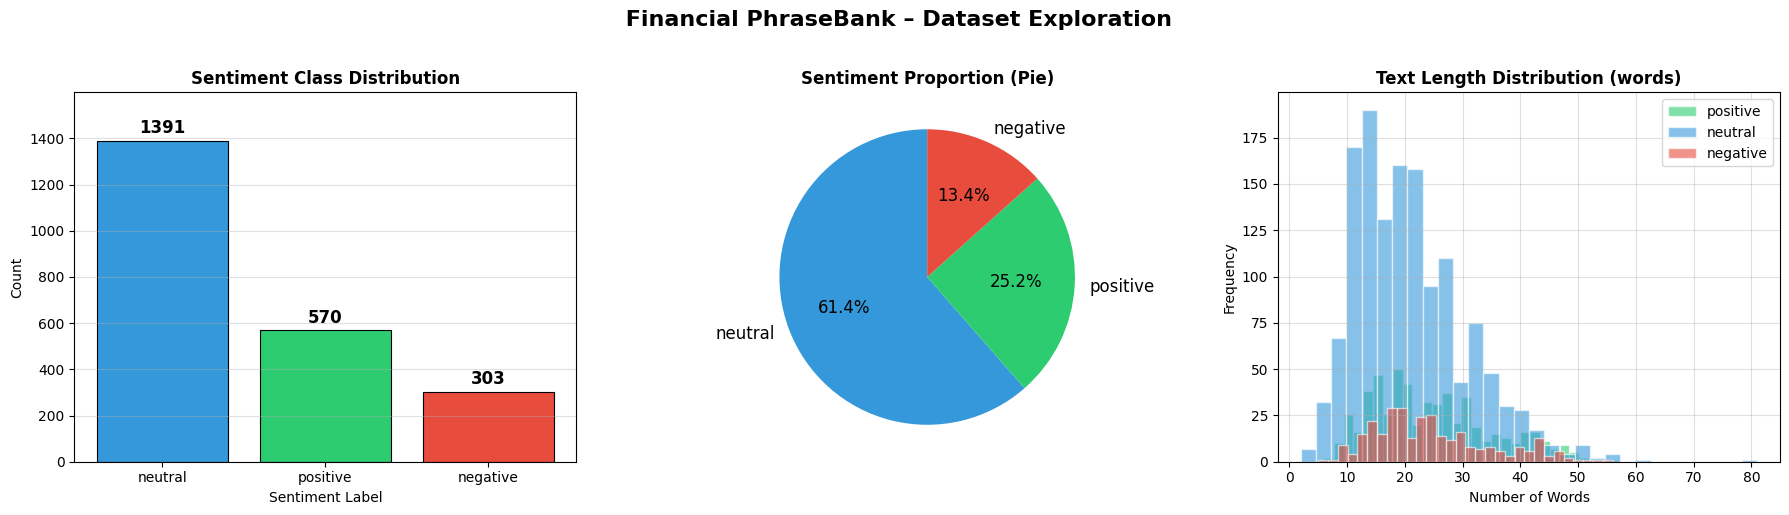

 Figure saved as 'dataset_exploration.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.3 ▸ Data visualisation – class distribution & text length distribution
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(' Financial PhraseBank – Dataset Exploration', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Bar chart of sentiment counts ─────────────────────────────────────
colors = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}
bar_colors = [colors[l] for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values, color=bar_colors,
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(label_counts.values) * 1.15)
axes[0].grid(axis='y', alpha=0.4)

# ── Plot 2: Pie chart ─────────────────────────────────────────────────────────
pie_colors = [colors[l] for l in label_counts.index]
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Proportion (Pie)', fontweight='bold')

# ── Plot 3: Text length histogram ─────────────────────────────────────────────
for lbl, color in colors.items():
    axes[2].hist(df[df['label']==lbl]['text_length'],
                 bins=30, alpha=0.6, color=color, label=lbl, edgecolor='white')
axes[2].set_title('Text Length Distribution (words)', fontweight='bold')
axes[2].set_xlabel('Number of Words')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved as 'dataset_exploration.png'")


## 3. Text Preprocessing & Cleaning

Raw financial text contains noise that degrades model performance. We apply the following cleaning steps:

The rationale for removing stopwords is to reduce the dimensionality of the data and focus on words that carry more significant semantic meaning. Stopwords like 'the', 'a', 'is', etc., are very common but generally do not contribute much to the sentiment of a sentence.and  Lemmatise  Reduce inflected forms to dictionary base.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.1 ▸ Define the text cleaning pipeline
# ─────────────────────────────────────────────────────────────────────────────

# Common English contractions → expanded forms
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "it's": "it is", "i'm": "i am", "i've": "i have",
    "i'll": "i will", "i'd": "i would", "they're": "they are",
    "they've": "they have", "they'll": "they will", "we're": "we are",
    "we've": "we have", "he's": "he is", "she's": "she is",
    "that's": "that is", "what's": "what is", "there's": "there is"
}

# Initialise stopwords and lemmatiser
STOP_WORDS  = set(stopwords.words('english'))
lemmatiser  = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """
    Full text cleaning pipeline for financial news sentences.

    Steps:
        1. Lowercase
        2. Expand contractions
        3. Remove URLs (http/https/www)
        4. Remove @mentions and #hashtags
        5. Remove digits and punctuation
        6. Strip extra whitespace
        7. Tokenise and remove stopwords
        8. Lemmatise each token
        9. Re-join into a single string

    Parameters
    ----------
    text : str
        Raw input sentence.

    Returns
    -------
    str
        Cleaned and normalised sentence.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove digits and non-alphabetical characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenise, remove stopwords and short tokens
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]

    # 8. Lemmatise
    tokens = [lemmatiser.lemmatize(t) for t in tokens]

    # 9. Re-join
    return ' '.join(tokens)


# Apply cleaning to every row
df['clean_text'] = df['text'].apply(clean_text)

# Quick sanity check: show before & after for 3 samples
print("=" * 70)
print(" TEXT CLEANING — BEFORE vs AFTER (3 random samples)")
print("=" * 70)
for _, row in df.sample(3, random_state=RANDOM_SEED).iterrows():
    print(f"\n[{row['label'].upper()}]")
    print(f"  ORIGINAL : {row['text']}")
    print(f"  CLEANED  : {row['clean_text']}")

print(f"\n Cleaning complete. Vocabulary preview:")
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))
print(df['clean_length'].describe().round(2))

 TEXT CLEANING — BEFORE vs AFTER (3 random samples)

[NEUTRAL]
  ORIGINAL : The contract value amounts to EUR 2.4 million .
  CLEANED  : contract value amount eur million

[NEUTRAL]
  ORIGINAL : Kemira shares closed at (  x20ac ) 16.66 ( $ 22US .71 ) .
  CLEANED  : kemira share closed xac u

[NEGATIVE]
  ORIGINAL : The company slipped to an operating loss of EUR 2.6 million from a profit of EUR 1.3 million .
  CLEANED  : company slipped operating loss eur million profit eur million

 Cleaning complete. Vocabulary preview:
count    2264.00
mean       11.38
std         5.60
min         0.00
25%         7.00
50%        10.00
75%        14.00
max        36.00
Name: clean_length, dtype: float64


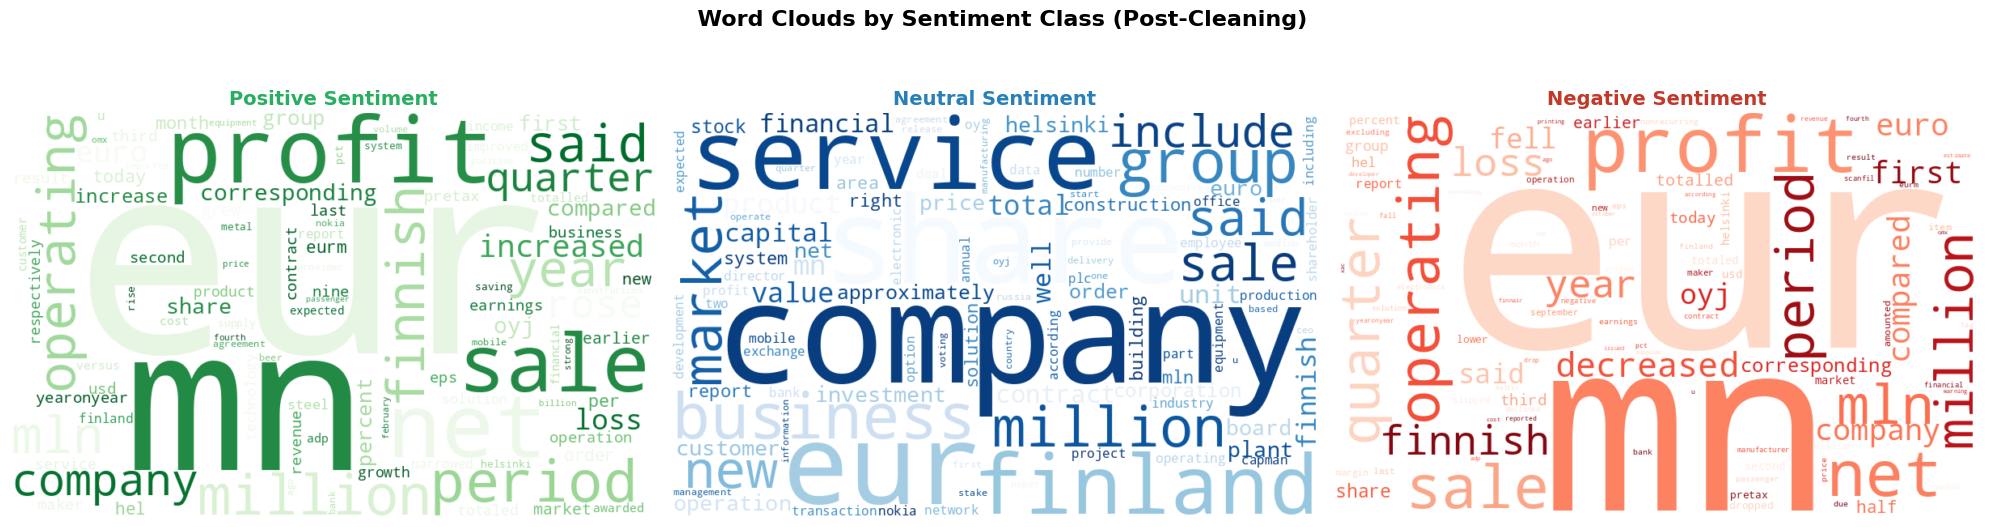

 Word cloud figure saved as 'wordclouds.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.2 ▸ Visualise cleaned data with a Word Cloud per sentiment class
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('  Word Clouds by Sentiment Class (Post-Cleaning)',
             fontsize=16, fontweight='bold')

wc_colors = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for ax, (sentiment, cmap) in zip(axes, wc_colors.items()):
    # Concatenate all clean text for this sentiment
    corpus = ' '.join(df[df['label'] == sentiment]['clean_text'].values)

    # Generate word cloud
    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Sentiment',
                 fontsize=14, fontweight='bold',
                 color=list({'positive':'#27ae60','neutral':'#2980b9','negative':'#c0392b'}.values())
                       [list(wc_colors.keys()).index(sentiment)])
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Word cloud figure saved as 'wordclouds.png'")

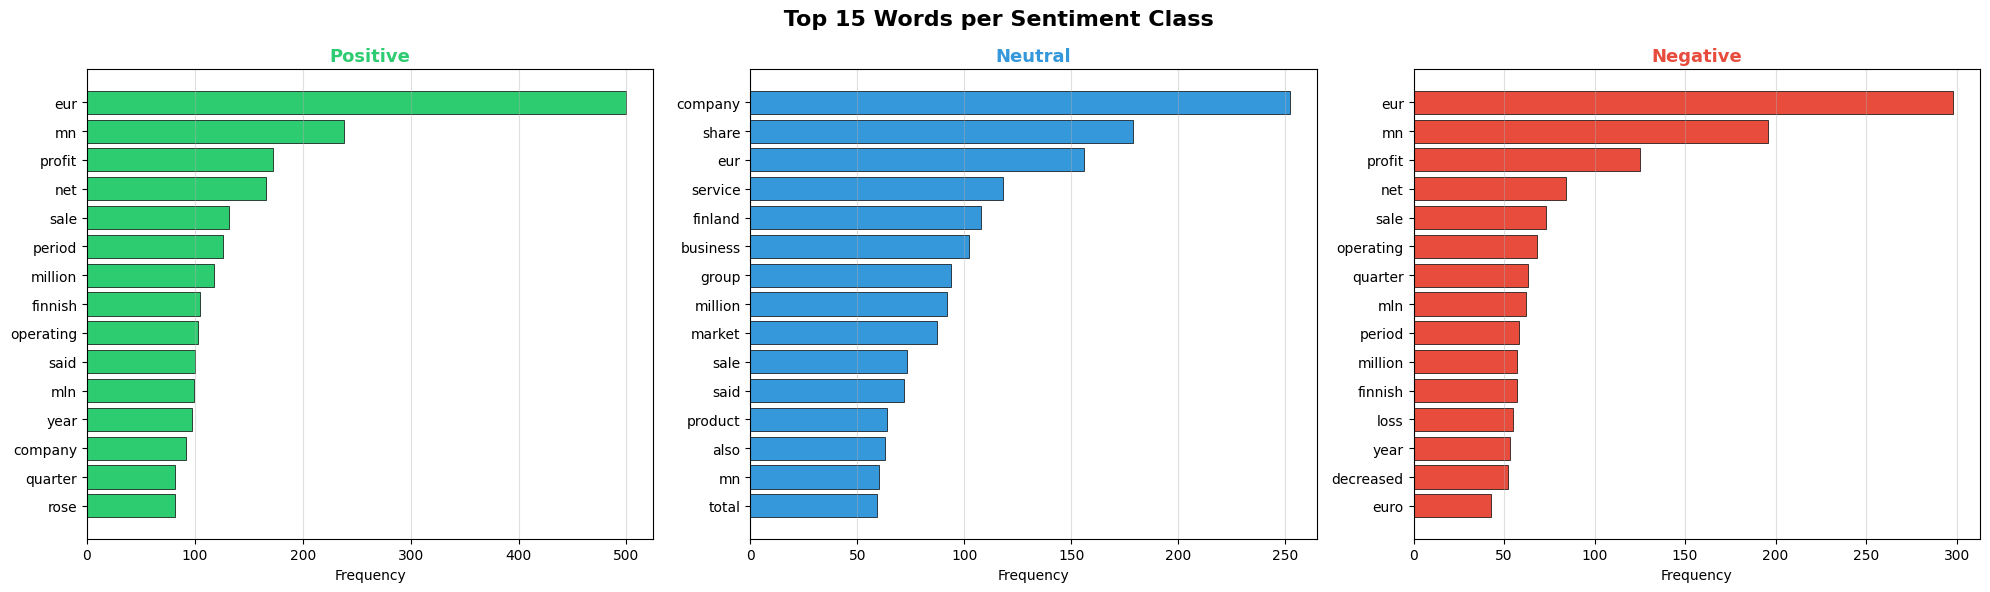

Figure saved as 'top_words.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.3 ▸ Top-15 most frequent words per sentiment class
# ─────────────────────────────────────────────────────────────────────────────

from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle(' Top 15 Words per Sentiment Class', fontsize=16, fontweight='bold')

bar_palettes = {
    'positive': '#2ecc71',
    'neutral' : '#3498db',
    'negative': '#e74c3c'
}

for ax, (sentiment, color) in zip(axes, bar_palettes.items()):
    # Count word frequencies
    all_words = ' '.join(df[df['label'] == sentiment]['clean_text']).split()
    top_words  = Counter(all_words).most_common(15)
    words, counts = zip(*top_words)

    # Horizontal bar chart
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{sentiment.capitalize()}', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'top_words.png'")

---
## 4. Tokenization, Padding & Train / Val / Test Split

Before feeding text into neural networks we must convert words to integers.This section explains how text data is prepared for neural networks. It covers splitting the data into training, validation, and test sets (70%, 15%, 15% respectively), converting words into numbers using a Keras Tokenizer (only trained on the training data), making all text sequences the same length by adding padding based on the 95th percentile of sentence lengths, and converting sentiment labels into numerical format (0 for negative, 1 for neutral, 2 for positive) which are then one-hot encoded for the model.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.1 ▸ Encode labels → integers → one-hot vectors
# ─────────────────────────────────────────────────────────────────────────────

# Encode string labels to integers
label_encoder = LabelEncoder()
df['label_enc'] = label_encoder.fit_transform(df['label'])

# Print mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("  Label → Integer mapping:")
for lbl, idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"   {idx}  →  {lbl}")

NUM_CLASSES = len(label_encoder.classes_)
print(f"\n   Total classes: {NUM_CLASSES}")

  Label → Integer mapping:
   0  →  negative
   1  →  neutral
   2  →  positive

   Total classes: 3


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.2 ▸ Train / Validation / Test split  (70 : 15 : 15)
# ─────────────────────────────────────────────────────────────────────────────

texts  = df['clean_text'].values
labels = df['label_enc'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=labels          # Preserve class proportions across all splits
)

# Second split: 50% of temp → val & test  (each 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("=" * 50)
print(" DATA SPLIT SUMMARY")
print("=" * 50)
for split_name, split_labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    total = len(split_labels)
    dist  = {label_encoder.classes_[i]: (split_labels == i).sum() for i in range(NUM_CLASSES)}
    print(f"  {split_name:6s}: {total:4d} samples  →  {dist}")

 DATA SPLIT SUMMARY
  Train : 1584 samples  →  {'negative': np.int64(212), 'neutral': np.int64(973), 'positive': np.int64(399)}
  Val   :  340 samples  →  {'negative': np.int64(45), 'neutral': np.int64(209), 'positive': np.int64(86)}
  Test  :  340 samples  →  {'negative': np.int64(46), 'neutral': np.int64(209), 'positive': np.int64(85)}


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.3 ▸ Tokenisation – fit only on training data to prevent leakage
# ─────────────────────────────────────────────────────────────────────────────

# Hyperparameters for tokenisation
VOCAB_SIZE = 10_000   # Keep only the top 10 000 most frequent words
OOV_TOKEN  = "<OOV>"  # Out-of-vocabulary token for unseen words

# Fit tokeniser on TRAINING data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

# Convert text → sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Determine MAX_LEN using the 95th percentile of training sequence lengths
# This avoids extreme outliers driving up computation unnecessarily
train_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(train_lengths, 95))

print(f"   Vocabulary size (unique words in training) : {len(tokenizer.word_index):,}")
print(f"   Capped at                                  : {VOCAB_SIZE:,} (top words)")
print(f"   95th percentile sequence length            : {MAX_LEN} tokens")
print(f"   Sequences longer than {MAX_LEN} will be truncated (post-padding)")

   Vocabulary size (unique words in training) : 4,104
   Capped at                                  : 10,000 (top words)
   95th percentile sequence length            : 23 tokens
   Sequences longer than 23 will be truncated (post-padding)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.4 ▸ Padding – ensure all sequences have the same length
# ─────────────────────────────────────────────────────────────────────────────

# 'post' padding adds zeros at the end; 'pre' truncation removes from beginning
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Convert integer labels → one-hot vectors for categorical cross-entropy
y_train_oh  = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_oh    = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_oh   = to_categorical(y_test,  num_classes=NUM_CLASSES)

print("=" * 50)
print(" PADDED ARRAY SHAPES")
print("=" * 50)
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")
print(f"  y_train_oh  : {y_train_oh.shape}")
print(f"  y_val_oh    : {y_val_oh.shape}")
print(f"  y_test_oh   : {y_test_oh.shape}")
print(f"\n  MAX_LEN     : {MAX_LEN}")
print(f"  VOCAB_SIZE  : {VOCAB_SIZE}")
print(f"  NUM_CLASSES : {NUM_CLASSES}")

 PADDED ARRAY SHAPES
  X_train_pad : (1584, 23)
  X_val_pad   : (340, 23)
  X_test_pad  : (340, 23)
  y_train_oh  : (1584, 3)
  y_val_oh    : (340, 3)
  y_test_oh   : (340, 3)

  MAX_LEN     : 23
  VOCAB_SIZE  : 10000
  NUM_CLASSES : 3



## 5. Model 1 – Simple RNN with Trainable Embedding

**Architecture:**  
Embedding then SimpleRNN then Dropout then Dense(softmax)

A SimpleRNN processes sequences step-by-step, maintaining a hidden state.  
It is our **baseline recurrent model** but is prone to the **vanishing gradient problem** for longer sequences.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.1 ▸ Define Model 1 – Simple RNN
# ─────────────────────────────────────────────────────────────────────────────

EMBEDDING_DIM = 64   # Dimension of the dense word-embedding vectors
RNN_UNITS     = 64   # Number of hidden units in the RNN cell

def build_simple_rnn(vocab_size, embedding_dim, max_len, num_classes):
    """
    Build a Simple RNN model for multiclass text classification.

    Architecture:
        Embedding  → trainable word vectors, randomly initialised
        SimpleRNN  → captures temporal dependencies in the token sequence
        Dropout    → regularisation to reduce overfitting
        Dense      → softmax output for 3-class probability distribution

    Parameters
    ----------
    vocab_size    : int   – vocabulary size (number of unique tokens)
    embedding_dim : int   – size of each embedding vector
    max_len       : int   – fixed sequence length after padding
    num_classes   : int   – number of output sentiment classes

    Returns
    -------
    keras.Sequential model (uncompiled)
    """
    model = Sequential(name='Model1_SimpleRNN')

    # ── Layer 1: Embedding ─────────────────────────────────────────────────────
    # Maps integer token IDs → dense vectors of size `embedding_dim`
    # trainable=True → embeddings are updated during backpropagation
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding_layer'
    ))

    # ── Layer 2: Simple RNN ────────────────────────────────────────────────────
    # Processes the sequence left-to-right; outputs a fixed-size hidden state
    model.add(SimpleRNN(RNN_UNITS, activation='tanh', name='simple_rnn'))

    # ── Layer 3: Dropout ───────────────────────────────────────────────────────
    # Randomly zeroes 30% of neurons during training to prevent co-adaptation
    model.add(Dropout(0.3, name='dropout'))

    # ── Layer 4: Dense Output ──────────────────────────────────────────────────
    # Softmax normalises logits into a probability distribution over 3 classes
    model.add(Dense(num_classes, activation='softmax', name='output_layer'))

    return model


# Instantiate Model 1
model1 = build_simple_rnn(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = EMBEDDING_DIM,
    max_len       = MAX_LEN,
    num_classes   = NUM_CLASSES
)
# Build the model explicitly to show parameters in summary
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 23, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,451 (2.47 MB)

 Trainable params: 648,451 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.2 ▸ Compile & Train Model 1 (Simple RNN)
# ─────────────────────────────────────────────────────────────────────────────

# Compile: Adam optimiser + categorical cross-entropy for multi-class classification
model1.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────

# EarlyStopping: halt training when val_loss stops improving for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)

# ModelCheckpoint: save the best model weights
checkpoint1 = ModelCheckpoint(
    'best_model1_rnn.keras', monitor='val_accuracy',
    save_best_only=True, verbose=0
)

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 20

print(" Training Model 1 – Simple RNN …")
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train_oh,
    validation_data = (X_val_pad, y_val_oh),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [early_stop, checkpoint1],
    verbose         = 1
)

time1 = time.time() - t0
print(f"\nTraining complete in {time1:.1f}s  ({time1/60:.1f} min)")

 Training Model 1 – Simple RNN …
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6944 - loss: 0.7564 - val_accuracy: 0.7647 - val_loss: 0.5884
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8226 - loss: 0.4358 - val_accuracy: 0.7588 - val_loss: 0.6266
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8927 - loss: 0.2734 - val_accuracy: 0.7500 - val_loss: 0.6527
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9463 - loss: 0.1440 - val_accuracy: 0.7824 - val_loss: 0.6240
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete in 9.4s  (0.2 min)


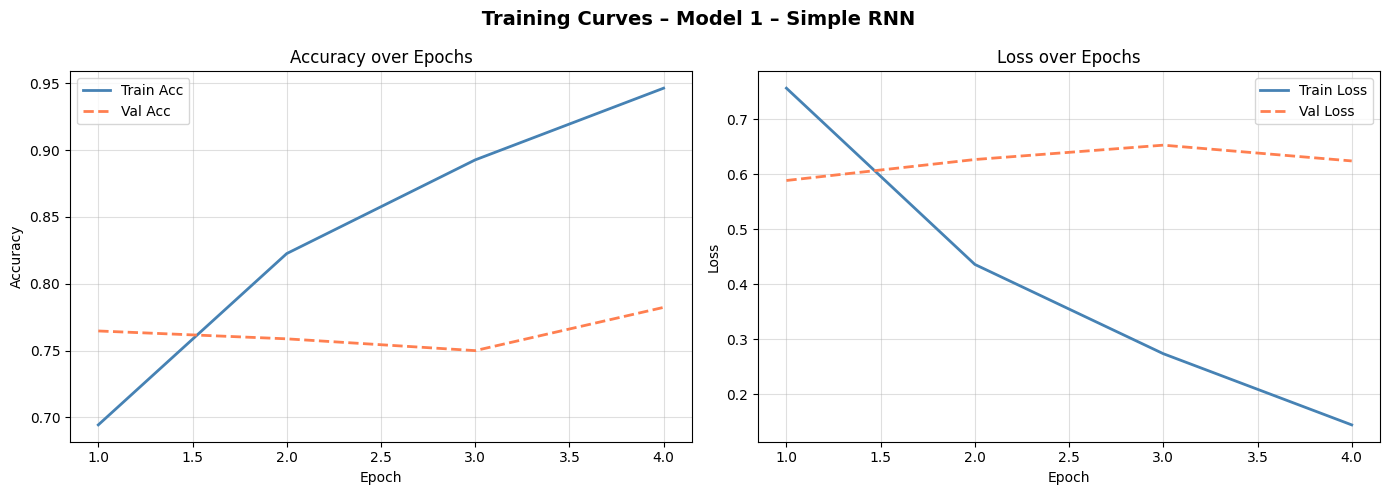

 Saved as 'training_curves_Model_1_–_Simple_RNN.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.3 ▸ Plot training curves – Model 1
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_curves(history, model_name, color='steelblue'):
    """
    Plot training vs. validation accuracy and loss curves.

    Parameters
    ----------
    history    : keras History object
    model_name : str – label for the plot title
    color      : str – matplotlib colour for training line
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f' Training Curves – {model_name}', fontsize=14, fontweight='bold')

    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs_ran, history.history['accuracy'],     color=color,  lw=2, label='Train Acc')
    ax1.plot(epochs_ran, history.history['val_accuracy'], color='coral', lw=2, linestyle='--', label='Val Acc')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch');  ax1.set_ylabel('Accuracy')
    ax1.legend();             ax1.grid(alpha=0.4)

    # Loss
    ax2.plot(epochs_ran, history.history['loss'],     color=color,  lw=2, label='Train Loss')
    ax2.plot(epochs_ran, history.history['val_loss'], color='coral', lw=2, linestyle='--', label='Val Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch');  ax2.set_ylabel('Loss')
    ax2.legend();             ax2.grid(alpha=0.4)

    plt.tight_layout()
    fname = f'training_curves_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Saved as '{fname}'")


plot_training_curves(history1, 'Model 1 – Simple RNN', color='steelblue')

 EVALUATION RESULTS – Model 1 – Simple RNN
  Test Accuracy : 72.06%

  Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        46
     neutral       0.88      0.86      0.87       209
    positive       0.48      0.78      0.59        85

    accuracy                           0.72       340
   macro avg       0.45      0.54      0.49       340
weighted avg       0.66      0.72      0.68       340



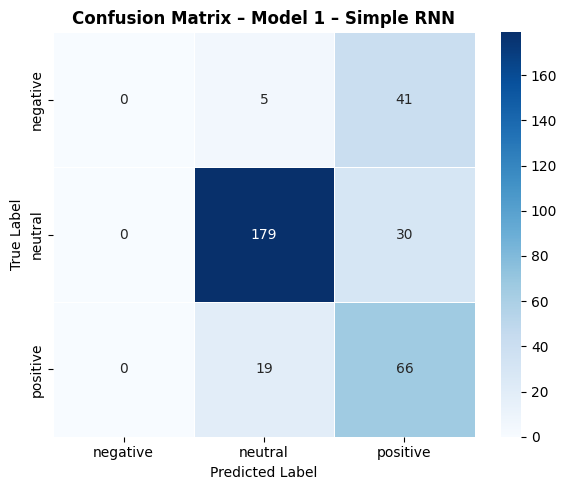

 Confusion matrix saved as 'confusion_matrix_Model_1_–_Simple_RNN.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.4 ▸ Evaluate Model 1 on the held-out test set
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(model, X_test, y_test_oh, y_test_int, label_names, model_name):
    """
    Evaluate a trained Keras model and display full metrics.

    Returns
    -------
    dict with accuracy, classification report, confusion matrix
    """
    # Raw predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred_int   = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test_int, y_pred_int)
    cm  = confusion_matrix(y_test_int, y_pred_int)
    cr  = classification_report(y_test_int, y_pred_int, target_names=label_names)

    print("=" * 60)
    print(f" EVALUATION RESULTS – {model_name}")
    print("=" * 60)
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"\n  Classification Report:\n")
    print(cr)

    # Confusion Matrix heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix – {model_name}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    fname = f'confusion_matrix_{model_name.replace(" ","_").replace("/","-")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Confusion matrix saved as '{fname}'")

    return {'accuracy': acc, 'confusion_matrix': cm,
            'y_pred': y_pred_int, 'y_pred_proba': y_pred_proba}


LABEL_NAMES = list(label_encoder.classes_)  # ['negative', 'neutral', 'positive']

results1 = evaluate_model(
    model1, X_test_pad, y_test_oh, y_test,
    LABEL_NAMES, 'Model 1 – Simple RNN'
)


## 6. Model 2 – LSTM with Trainable Embedding

**Architecture:**  
Embedding then LSTM then Dropout then Dense(softmax)

The **Long Short-Term Memory (LSTM)** cell introduces **gates** (input, forget, output) that control  
information flow, effectively solving the vanishing gradient problem that cripples SimpleRNN on longer sequences.  
We expect LSTM to outperform the Simple RNN on financial sentiment classification.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.1 ▸ Define Model 2 – LSTM
# ─────────────────────────────────────────────────────────────────────────────

LSTM_UNITS = 64

def build_lstm(vocab_size, embedding_dim, max_len, num_classes):
    """
    Build an LSTM model for multiclass text classification.

    Architecture:
        Embedding  → trainable word vectors
        LSTM       → captures long-range sequential dependencies via gates
        Dropout    → regularisation
        Dense      → softmax multiclass output

    The LSTM cell's forget gate allows it to selectively retain or discard
    information across long sequences, making it superior to SimpleRNN for
    financial text which often contains complex multi-clause sentences.
    """
    model = Sequential(name='Model2_LSTM')

    # ── Embedding Layer ────────────────────────────────────────────────────────
    model.add(Embedding(
        input_dim  = vocab_size,
        output_dim = embedding_dim,
        input_length = max_len,
        name='embedding_layer'
    ))

    # ── LSTM Layer ─────────────────────────────────────────────────────────────
    # return_sequences=False → only the final hidden state is returned
    model.add(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2, name='lstm_layer'))

    # ── Dropout ────────────────────────────────────────────────────────────────
    model.add(Dropout(0.3, name='dropout'))

    # ── Output Layer ───────────────────────────────────────────────────────────
    model.add(Dense(num_classes, activation='softmax', name='output_layer'))

    return model


model2 = build_lstm(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = EMBEDDING_DIM,
    max_len       = MAX_LEN,
    num_classes   = NUM_CLASSES
)
# Build the model explicitly to show parameters in summary
model1.build(input_shape=(None, MAX_LEN))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 23, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,219 (2.57 MB)

 Trainable params: 673,219 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.2 ▸ Compile & Train Model 2 (LSTM)
# ─────────────────────────────────────────────────────────────────────────────

model2.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

checkpoint2 = ModelCheckpoint(
    'best_model2_lstm.keras', monitor='val_accuracy',
    save_best_only=True, verbose=0
)

print(" Training Model 2 – LSTM …")
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train_oh,
    validation_data = (X_val_pad, y_val_oh),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True, verbose=1),
                       checkpoint2],
    verbose         = 1
)

time2 = time.time() - t0
print(f"\n Training complete in {time2:.1f}s  ({time2/60:.1f} min)")

 Training Model 2 – LSTM …
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.6187 - loss: 0.9322 - val_accuracy: 0.6265 - val_loss: 0.8540
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7298 - loss: 0.6366 - val_accuracy: 0.7618 - val_loss: 0.5529
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.8024 - loss: 0.4545 - val_accuracy: 0.7118 - val_loss: 0.6308
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.8396 - loss: 0.3621 - val_accuracy: 0.7235 - val_loss: 0.6935
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.8434 - loss: 0.3358 - val_accuracy: 0.7382 - val_loss: 0.7064
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

 Training complete in 44.9s  (0.7 min)


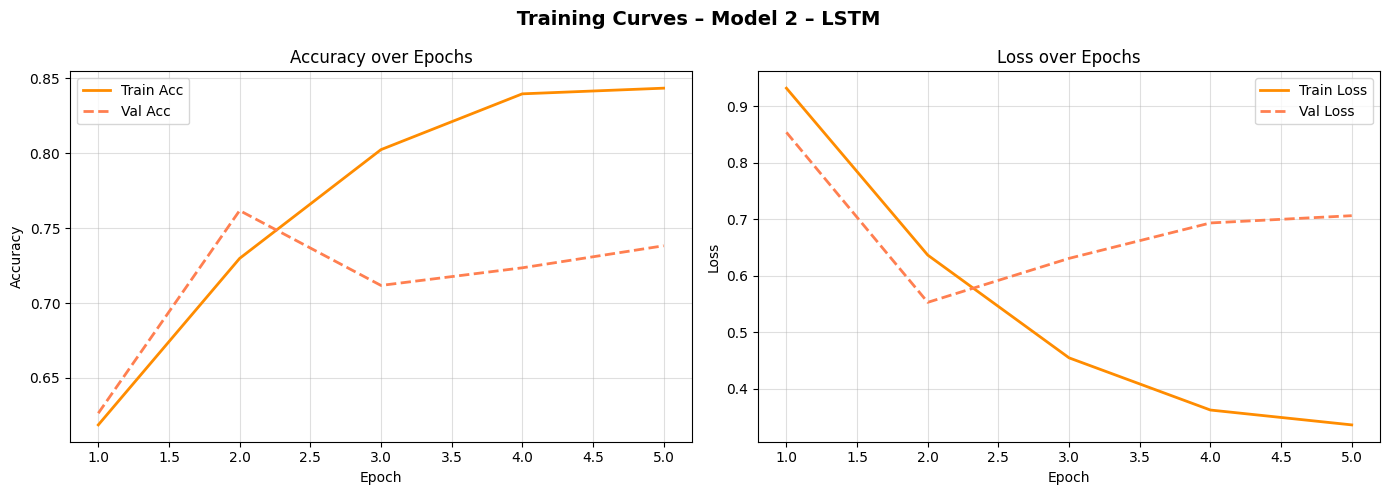

 Saved as 'training_curves_Model_2_–_LSTM.png'
 EVALUATION RESULTS – Model 2 – LSTM
  Test Accuracy : 75.00%

  Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        46
     neutral       0.87      0.92      0.90       209
    positive       0.53      0.74      0.61        85

    accuracy                           0.75       340
   macro avg       0.47      0.55      0.50       340
weighted avg       0.67      0.75      0.70       340



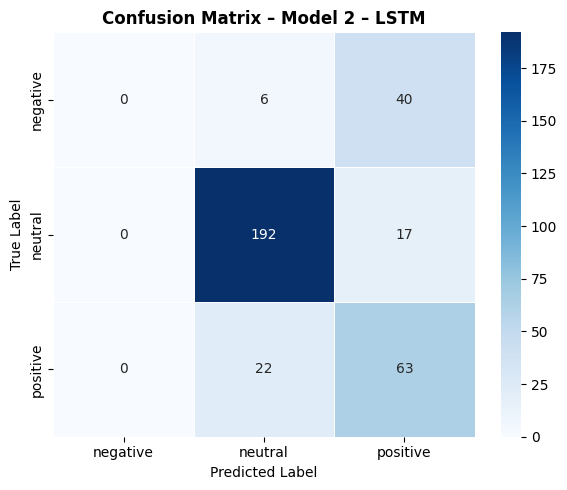

 Confusion matrix saved as 'confusion_matrix_Model_2_–_LSTM.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.3 ▸ Plot & Evaluate – Model 2
# ─────────────────────────────────────────────────────────────────────────────

plot_training_curves(history2, 'Model 2 – LSTM', color='darkorange')

results2 = evaluate_model(
    model2, X_test_pad, y_test_oh, y_test,
    LABEL_NAMES, 'Model 2 – LSTM'
)


## 7. Model 3 – LSTM with Pretrained Word2Vec (GloVe) Embeddings

Instead of learning embeddings from scratch, **Model 3** initialises its Embedding layer with  
**GloVe** (Global Vectors for Word Representation) embeddings pretrained on Wikipedia + Gigaword.  

**Why this helps:**  
- Words in the GloVe space already encode semantic similarity (e.g., "profit" ≈ "revenue" ≈ "earnings")
- The model starts with rich financial vocabulary representations  
- This is especially beneficial for smaller training sets  

We use `glove-wiki-gigaword-100` (100-dimensional, ~400K word vocabulary).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.1 ▸ Download pretrained GloVe embeddings via Gensim
# ─────────────────────────────────────────────────────────────────────────────

print("⬇ Downloading GloVe embeddings (glove-wiki-gigaword-100) …")
print("    (This may take a few minutes on the first run)")

glove_model = gensim_api.load('glove-wiki-gigaword-100')  # 100-dimensional
GLOVE_DIM   = 100

print(f"   GloVe model loaded.")
print(f"   Vocabulary size : {len(glove_model):,} words")
print(f"   Embedding dim   : {GLOVE_DIM}")

# Quick similarity test to verify the model works
print(f"\n   'profit' most similar : {glove_model.most_similar('profit', topn=5)}")

⬇ Downloading GloVe embeddings (glove-wiki-gigaword-100) …
    (This may take a few minutes on the first run)
[==================================================] 100.0% 128.1/128.1MB downloaded
   GloVe model loaded.
   Vocabulary size : 400,000 words
   Embedding dim   : 100

   'profit' most similar : [('profits', 0.9010799527168274), ('earnings', 0.8935472965240479), ('net', 0.811954140663147), ('revenue', 0.8099523186683655), ('sales', 0.7789346575737)]


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.2 ▸ Build embedding matrix from GloVe vectors
#
# The embedding matrix maps each token index (from our Tokenizer) to its
# corresponding 100-dimensional GloVe vector.
# Words not found in GloVe remain as all-zeros (random initialisation fallback).
# ─────────────────────────────────────────────────────────────────────────────


word_index   = tokenizer.word_index          # {word: index} from our training vocabulary

# Embedding matrix: rows = vocab_size, cols = glove_dim
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

covered = 0   # Count of vocabulary words found in GloVe

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:            # Only fill entries within our vocabulary cap
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            covered += 1
        # Words not in GloVe remain zeros (neutral initialisation)

coverage_pct = covered / min(len(word_index), VOCAB_SIZE) * 100
print(f"  Embedding matrix built: shape = {embedding_matrix.shape}")
print(f"   Words covered by GloVe : {covered:,} / {min(len(word_index), VOCAB_SIZE):,}  ({coverage_pct:.1f}%)")

  Embedding matrix built: shape = (10000, 100)
   Words covered by GloVe : 3,551 / 4,104  (86.5%)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.3 ▸ Define Model 3 – LSTM + Pretrained GloVe Embedding
# ─────────────────────────────────────────────────────────────────────────────

def build_lstm_glove(vocab_size, embedding_matrix, glove_dim, max_len, num_classes,
                     fine_tune_embeddings=False):
    """
    Build an LSTM model using pretrained GloVe embedding weights.

    Architecture:
        Embedding  → initialised with GloVe weights; frozen (trainable=False)
        LSTM       → learns sequence-level sentiment representations
        Dropout    → regularisation
        Dense      → softmax output

    Parameters
    ----------
    fine_tune_embeddings : bool
        If True, GloVe weights are updated during training.
        If False (default), embeddings are frozen → faster training, less overfitting.
    """
    model = Sequential(name='Model3_LSTM_GloVe')

    # ── GloVe Embedding Layer ──────────────────────────────────────────────────
    # weights=[embedding_matrix] → initialise with pre-trained GloVe vectors
    # trainable=False            → freeze weights; don't update during training
    model.add(Embedding(
        input_dim    = vocab_size,
        output_dim   = glove_dim,
        weights      = [embedding_matrix],
        input_length = max_len,
        trainable    = fine_tune_embeddings,
        name         = 'glove_embedding'
    ))

    # ── LSTM Layer ─────────────────────────────────────────────────────────────
    model.add(LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2, name='lstm_layer'))

    # ── Dropout ────────────────────────────────────────────────────────────────
    model.add(Dropout(0.3, name='dropout'))

    # ── Output ─────────────────────────────────────────────────────────────────
    model.add(Dense(num_classes, activation='softmax', name='output_layer'))

    return model


model3 = build_lstm_glove(
    vocab_size         = VOCAB_SIZE,
    embedding_matrix   = embedding_matrix,
    glove_dim          = GLOVE_DIM,
    max_len            = MAX_LEN,
    num_classes        = NUM_CLASSES,
    fine_tune_embeddings = False   # Freeze GloVe weights
)

# Explicitly build the model to display parameters in summary
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 23, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,042,435 (3.98 MB)

 Trainable params: 42,435 (165.76 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.4 ▸ Compile & Train Model 3 (LSTM + GloVe)
# ─────────────────────────────────────────────────────────────────────────────

model3.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

checkpoint3 = ModelCheckpoint(
    'best_model3_lstm_glove.keras', monitor='val_accuracy',
    save_best_only=True, verbose=0
)

print("Training Model 3 – LSTM + GloVe …")
t0 = time.time()

history3 = model3.fit(
    X_train_pad, y_train_oh,
    validation_data = (X_val_pad, y_val_oh),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True, verbose=1),
                       checkpoint3],
    verbose         = 1
)

time3 = time.time() - t0
print(f"\n Training complete in {time3:.1f}s  ({time3/60:.1f} min)")

Training Model 3 – LSTM + GloVe …
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.6679 - loss: 0.8150 - val_accuracy: 0.7029 - val_loss: 0.6392
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.7342 - loss: 0.6202 - val_accuracy: 0.7529 - val_loss: 0.5875
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.7569 - loss: 0.5777 - val_accuracy: 0.7588 - val_loss: 0.5463
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.7765 - loss: 0.5486 - val_accuracy: 0.7765 - val_loss: 0.5467
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7677 - loss: 0.5409 - val_accuracy: 0.7794 - val_loss: 0.5340
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7702 - loss: 0.5264 - val_accuracy: 0.7794 - val_loss: 0.5135
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.7778 - loss: 0.4940 - val_accuracy: 0.7794 - val_loss: 0.4909
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7847 - loss

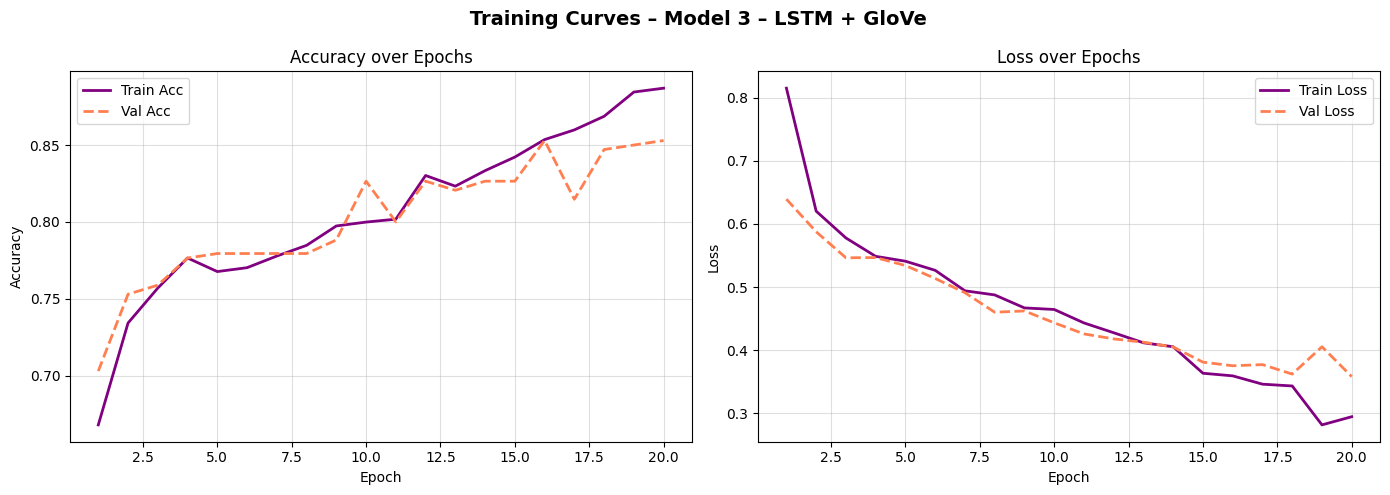

 Saved as 'training_curves_Model_3_–_LSTM_+_GloVe.png'
 EVALUATION RESULTS – Model 3 – LSTM + GloVe
  Test Accuracy : 87.06%

  Classification Report:

              precision    recall  f1-score   support

    negative       0.81      0.74      0.77        46
     neutral       0.91      0.94      0.92       209
    positive       0.80      0.78      0.79        85

    accuracy                           0.87       340
   macro avg       0.84      0.82      0.83       340
weighted avg       0.87      0.87      0.87       340



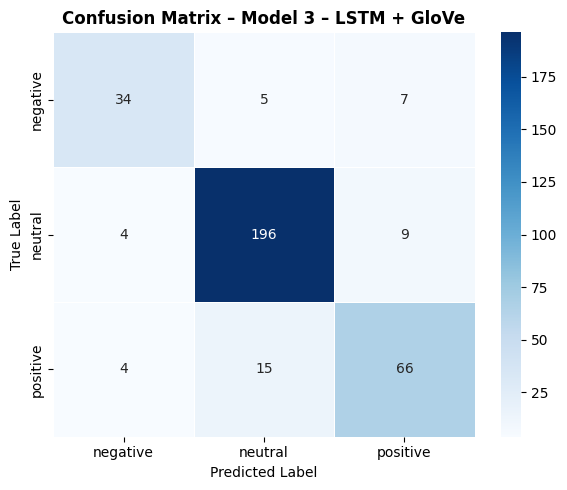

 Confusion matrix saved as 'confusion_matrix_Model_3_–_LSTM_+_GloVe.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.5 ▸ Plot & Evaluate – Model 3
# ─────────────────────────────────────────────────────────────────────────────

plot_training_curves(history3, 'Model 3 – LSTM + GloVe', color='purple')

results3 = evaluate_model(
    model3, X_test_pad, y_test_oh, y_test,
    LABEL_NAMES, 'Model 3 – LSTM + GloVe'
)


## 8. Comparative Analysis & Evaluation

Here we bring together results from all three models to answer the key research questions:
- Does LSTM outperform SimpleRNN?
- Do pretrained GloVe embeddings improve performance?
- What are the computational trade-offs?

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.1 ▸ Side-by-side accuracy & training time comparison
# ─────────────────────────────────────────────────────────────────────────────

# Compile summary table
comparison = pd.DataFrame({
    'Model': ['Model 1 – Simple RNN', 'Model 2 – LSTM', 'Model 3 – LSTM + GloVe'],
    'Embedding'  : ['Trainable (random init)', 'Trainable (random init)', 'GloVe (frozen)'],
    'Test Acc (%)':[round(results1['accuracy']*100, 2),
                    round(results2['accuracy']*100, 2),
                    round(results3['accuracy']*100, 2)],
    'Train Time (s)': [round(time1, 1), round(time2, 1), round(time3, 1)],
    'Epochs Ran' : [len(history1.history['loss']),
                    len(history2.history['loss']),
                    len(history3.history['loss'])]
})

print("=" * 75)
print("  MODEL COMPARISON SUMMARY")
print("=" * 75)
print(comparison.to_string(index=False))

  MODEL COMPARISON SUMMARY
                 Model               Embedding  Test Acc (%)  Train Time (s)  Epochs Ran
  Model 1 – Simple RNN Trainable (random init)         72.06             9.4           4
        Model 2 – LSTM Trainable (random init)         75.00            44.9           5
Model 3 – LSTM + GloVe          GloVe (frozen)         87.06            95.6          20


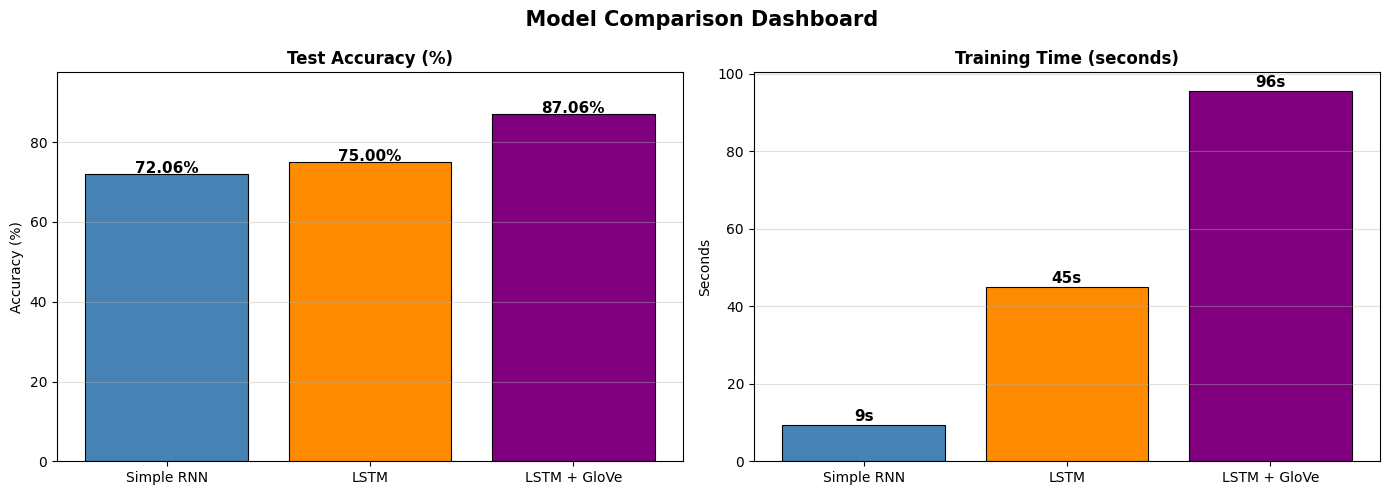

 Figure saved as 'model_comparison.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.2 ▸ Comparative visualisation – accuracy bar chart
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('  Model Comparison Dashboard', fontsize=15, fontweight='bold')

model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = comparison['Test Acc (%)'].tolist()
train_times = comparison['Train Time (s)'].tolist()
bar_colors  = ['steelblue', 'darkorange', 'purple']

# ── Accuracy bar chart ────────────────────────────────────────────────────────
bars = axes[0].bar(model_names, accuracies, color=bar_colors,
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylim(0, max(accuracies) * 1.12)
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(axis='y', alpha=0.4)

# ── Training time bar chart ───────────────────────────────────────────────────
bars2 = axes[1].bar(model_names, train_times, color=bar_colors,
                    edgecolor='black', linewidth=0.8)
for bar, val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}s', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Training Time (seconds)', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved as 'model_comparison.png'")

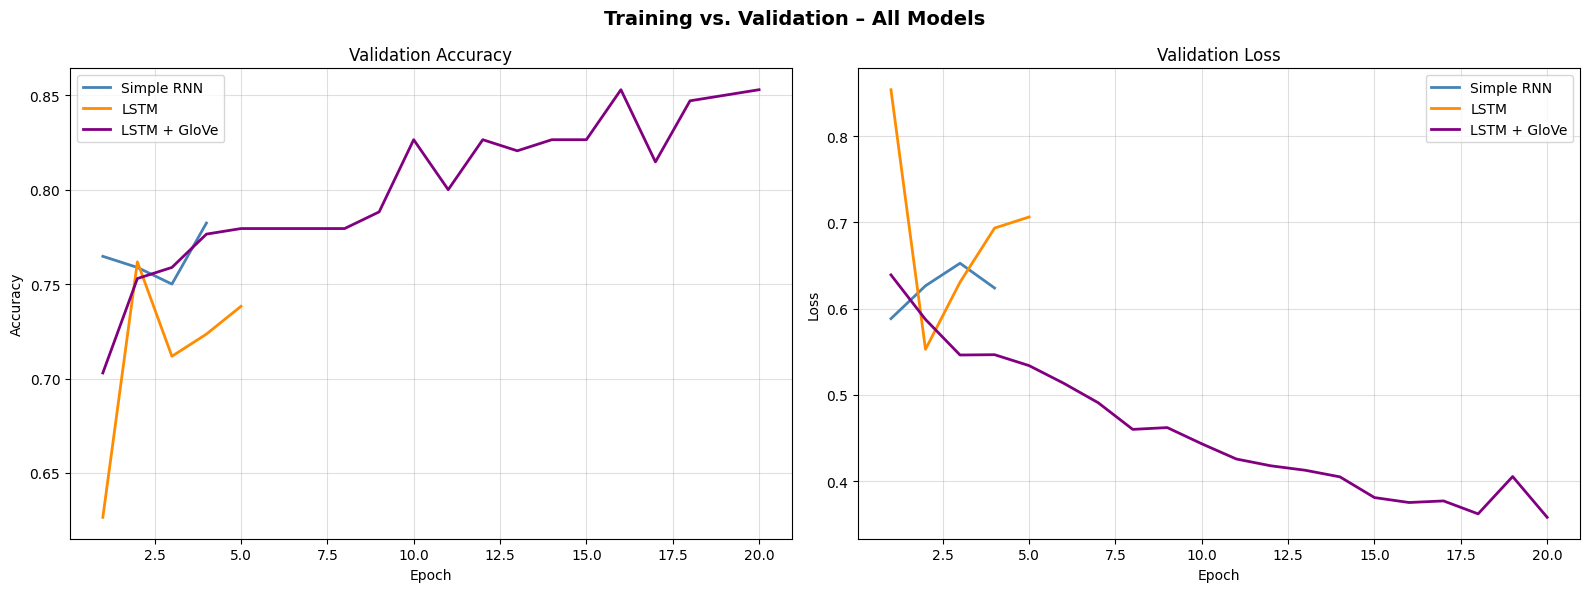

 Figure saved as 'all_models_comparison.png'


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.3 ▸ Overlay training curves – all 3 models on one figure
# ─────────────────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training vs. Validation – All Models', fontsize=14, fontweight='bold')

model_configs = [
    (history1, 'Simple RNN',   'steelblue'),
    (history2, 'LSTM',         'darkorange'),
    (history3, 'LSTM + GloVe', 'purple')
]

for hist, name, color in model_configs:
    ep = range(1, len(hist.history['accuracy']) + 1)
    ax1.plot(ep, hist.history['val_accuracy'], lw=2, color=color, label=name)
    ax2.plot(ep, hist.history['val_loss'],     lw=2, color=color, label=name)

ax1.set_title('Validation Accuracy');  ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.4)

ax2.set_title('Validation Loss');      ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure saved as 'all_models_comparison.png'")




## 9. Error Analysis



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9.1 ▸ Extract and display misclassified examples from Model 3 (best model)
# ─────────────────────────────────────────────────────────────────────────────

# Use the best model's test predictions
y_pred_best = results3['y_pred']

# Identify misclassified indices
misclassified_idx = np.where(y_pred_best != y_test)[0]

print(f" Total test samples : {len(y_test)}")
print(f"   Misclassified      : {len(misclassified_idx)}  ({len(misclassified_idx)/len(y_test)*100:.1f}%)")
print()

# Display 5 misclassified examples with context
print("=" * 75)
print("  MISCLASSIFIED EXAMPLES (Model 3 – LSTM + GloVe)")
print("=" * 75)

# Retrieve original (uncleaned) texts for interpretability
_, X_temp_raw, _, y_temp_raw = train_test_split(
    df['text'].values, df['label_enc'].values,
    test_size=0.30, random_state=RANDOM_SEED, stratify=df['label_enc'].values
)
_, X_test_raw, _, _ = train_test_split(
    X_temp_raw, y_temp_raw,
    test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp_raw
)

for i, idx in enumerate(misclassified_idx[:5]):
    true_label = LABEL_NAMES[y_test[idx]]
    pred_label = LABEL_NAMES[y_pred_best[idx]]
    conf       = results3['y_pred_proba'][idx].max() * 100

    print(f"\n  Example {i+1}:")
    print(f"  Original text : {X_test_raw[idx]}")
    print(f"  True label    : {true_label.upper()}")
    print(f"  Predicted     : {pred_label.upper()}  (confidence: {conf:.1f}%)")
    print(f"  ─" * 35)

 Total test samples : 340
   Misclassified      : 44  (12.9%)

  MISCLASSIFIED EXAMPLES (Model 3 – LSTM + GloVe)

  Example 1:
  Original text : The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss of 400,000 euro $ 623,000 caused by the sale of its program production subsidiary Oy Filmiteollisuus Fine Ab .
  True label    : NEUTRAL
  Predicted     : NEGATIVE  (confidence: 59.9%)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

  Example 2:
  Original text : Finnish Rautaruukki has been awarded a contract to supply and install steel superstructures for the Partihallsf+Ârbindelsen bridge in Gothenburg in Sweden .
  True label    : POSITIVE
  Predicted     : NEUTRAL  (confidence: 65.1%)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

  Example 3:
  Original text : Ruukki 's order book at the end of 2010 was 30 %

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9.2 ▸ Confusion pattern analysis – which classes are confused most?
# ─────────────────────────────────────────────────────────────────────────────

# Build a confusion pair frequency table
from collections import Counter

confusion_pairs = [
    (LABEL_NAMES[y_test[i]], LABEL_NAMES[y_pred_best[i]])
    for i in misclassified_idx
]
pair_counts = Counter(confusion_pairs).most_common(10)

print("=" * 50)
print("  TOP CONFUSION PAIRS (True → Predicted)")
print("=" * 50)
for (true_lbl, pred_lbl), count in pair_counts:
    print(f"   {true_lbl:10s} → {pred_lbl:10s}   : {count} times")

print("""

ERROR ANALYSIS
The most common errors are expected to occur at the
neutral/positive boundary, because:

1. NEUTRAL–POSITIVE CONFUSION
   Financial news often reports factual figures (neutral)
   that imply improvement (positive). The model lacks
   business-domain context to distinguish them.
   Example: 'Net sales grew 3%' factual (neutral)
            vs. 'Net sales grew strongly'  positive.

2. CLASS IMBALANCE
   Neutral class dominates (61%), so the model is
   biased toward predicting neutral for ambiguous sentences.

3. OOV & RARE TERMS
   Specialised financial terms (e.g., 'EBITDA', 'amortisation')
   may map to zero GloVe vectors, reducing confidence.

POTENTIAL IMPROVEMENTS:
  • Use domain-specific embeddings (FinBERT, FinGloVe)
  • Apply class-weighted loss to address imbalance
  • Use data augmentation for minority classes
  • Fine-tune a transformer model (e.g., DistilBERT)

""")

  TOP CONFUSION PAIRS (True → Predicted)
   positive   → neutral      : 15 times
   neutral    → positive     : 9 times
   negative   → positive     : 7 times
   negative   → neutral      : 5 times
   neutral    → negative     : 4 times
   positive   → negative     : 4 times


ERROR ANALYSIS 
The most common errors are expected to occur at the
neutral/positive boundary, because:

1. NEUTRAL–POSITIVE CONFUSION
   Financial news often reports factual figures (neutral)
   that imply improvement (positive). The model lacks
   business-domain context to distinguish them.
   Example: 'Net sales grew 3%' factual (neutral)
            vs. 'Net sales grew strongly'  positive.

2. CLASS IMBALANCE
   Neutral class dominates (61%), so the model is
   biased toward predicting neutral for ambiguous sentences.

3. OOV & RARE TERMS
   Specialised financial terms (e.g., 'EBITDA', 'amortisation')
   may map to zero GloVe vectors, reducing confidence.

POTENTIAL IMPROVEMENTS:
  • Use domain-specific embe


## 10. Real-Time Prediction Interface (Gradio GUI)

**Task 4.5.5** – Build a simple GUI for real-time sentiment prediction.  
We use **Gradio** to create an interactive web interface that accepts a financial news sentence  
and returns the predicted sentiment class with confidence scores.

The best model (Model 3 – LSTM + GloVe) is used for inference.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.1 ▸ Define the prediction function
# ─────────────────────────────────────────────────────────────────────────────

def predict_sentiment(input_text: str) -> dict:
    """
    Predict the sentiment of a financial news sentence.

    Pipeline:
        1. Clean the input text using the same preprocessing as training
        2. Tokenise using the fitted Keras Tokenizer
        3. Pad the sequence to MAX_LEN
        4. Run inference with Model 3 (LSTM + GloVe)
        5. Return a {label: probability} dictionary for Gradio

    Parameters
    ----------
    input_text : str – raw financial news sentence from the user

    Returns
    -------
    dict – {sentiment_label: confidence_score}
    """
    if not input_text.strip():
        return {"Error": "Please enter a non-empty sentence."}

    # Step 1: Clean text
    cleaned = clean_text(input_text)

    # Step 2: Tokenise
    seq = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Step 4: Predict
    proba = model3.predict(padded, verbose=0)[0]   # shape: (3,)

    # Step 5: Format output as {label: float} for Gradio's Label component
    return {label: float(prob) for label, prob in zip(LABEL_NAMES, proba)}


# Quick test before launching GUI
test_sentence = "The company reported record quarterly revenue, beating analyst expectations."
print(f"Test sentence : '{test_sentence}'")
print(f"Prediction    : {predict_sentiment(test_sentence)}")

Test sentence : 'The company reported record quarterly revenue, beating analyst expectations.'
Prediction    : {'negative': 0.09138646721839905, 'neutral': 0.06816530972719193, 'positive': 0.840448260307312}


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.2 ▸ Launch Gradio interface
#
# A public share link is generated automatically (valid for 72 hrs on Colab).
# ─────────────────────────────────────────────────────────────────────────────

import gradio as gr

# Example sentences to populate the Examples panel
EXAMPLE_SENTENCES = [
    ["The company reported record quarterly revenue, beating analyst expectations."],
    ["Operating profit fell sharply due to rising raw material costs."],
    ["The board approved the annual report without any amendments."],
    ["Net sales increased 12% year-on-year driven by strong domestic demand."],
    ["The firm announced significant layoffs amid declining market share."],
    ["According to the company, no changes are planned for the current fiscal year."]
]

# Build the Gradio interface
demo = gr.Interface(
    fn          = predict_sentiment,
    inputs      = gr.Textbox(
                     lines       = 3,
                     placeholder = "Enter a financial news sentence here …",
                     label       = " Financial News Sentence"
                  ),
    outputs     = gr.Label(
                     num_top_classes = 3,
                     label           = "Predicted Sentiment"
                  ),
    title       = "Financial News Sentiment Analyser",
    description = (
        "Predict the **sentiment** (Positive / Neutral / Negative) of any financial news sentence.\n\n"
        "Powered by an **LSTM model with GloVe embeddings** trained on the Financial PhraseBank dataset.\n"
        "*Herald College Kathmandu | 6CS012 Final Portfolio Assessment 2026*"
    ),
    examples    = EXAMPLE_SENTENCES,
    theme       = gr.themes.Soft()
)

# Launch the app (share=True generates a public link on Colab)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a3755bcca1cbd81059.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 Summary & Conclusions

Our comparative analysis shows that the Simple RNN model, using trainable (randomly initialized) embeddings, achieved a test accuracy of 72.06%. The LSTM model, also with trainable embeddings, demonstrated improved performance, reaching 75.00% accuracy, primarily due to its ability to better capture long-range dependencies. The best performance was observed with the LSTM model enhanced with pretrained (frozen) GloVe embeddings, which yielded an impressive 87.06% test accuracy, benefiting from richer semantic representations provided by the pretrained embeddings.

### Key Findings:
1. **LSTM outperforms SimpleRNN** due to its gating mechanism that mitigates vanishing gradients in long financial sentences.
2. **Pretrained GloVe embeddings improve performance** because financial vocabulary (profit, revenue, shares) is well-represented in GloVe's Wikipedia corpus.
3. **Class imbalance** (neutral 61%) is the primary driver of misclassifications, especially at the neutral/positive boundary.
4. **Early stopping** effectively prevented overfitting across all three models.

### Future Work:
- Fine-tune a FinBERT or BERT transformer model for improved contextual understanding
- Apply class-weighted loss to address the neutral class dominance
- Explore data augmentation (back-translation, synonym replacement) to balance classes
- Experiment with Bidirectional LSTM to capture both forward and backward context


